Самым первым этапом будет загрузка собранного датасета из различных источников

In [1]:
!pip install Pillow

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from PIL import Image, ImageDraw, ImageFont

In [3]:
!pip install datasets matplotlib manga109api

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 3.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 17.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 27.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.1/243.1 kB 36.9 MB/s eta 0:00:00
     ━━━

In [ ]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import sys
import zipfile
import os
from pathlib import Path

# Добавляем путь к пакетам
sys.path.append('/home/user/.local/lib/python3.8/site-packages')

# Функция для разархивирования ZIP с НЕ-UTF8 кодировкой (для манги)
def razarhiviruj_manga(zip_path, extract_to, encoding='cp932'):
    """
    Разархивирует ZIP файл с японской/китайской кодировкой имен файлов
    """
    print(f"Разархивирую {zip_path}...")
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        for i, member in enumerate(z.infolist()):
            # Фиксим кодировку имен файлов: cp437 -> нужная кодировка
            try:
                # Для японских манга часто cp932 (Shift-JIS)
                filename = member.filename.encode('cp437').decode(encoding)
            except:
                # Если не сработало, пробуем другие популярные кодировки
                for enc in ['cp932', 'shiftjis', 'euc_jp', 'gbk', 'latin1']:
                    try:
                        filename = member.filename.encode('cp437').decode(enc)
                        print(f"✓ Использую кодировку: {enc}")
                        break
                    except:
                        continue
                else:
                    filename = member.filename  # Оставляем как есть
            
            # Создаем полный путь
            target_path = Path(extract_to) / filename
            
            # Создаем папки если нужно
            target_path.parent.mkdir(parents=True, exist_ok=True)
            
            print(f"[{i+1}] {filename}")
            
            # Извлекаем файл
            with open(target_path, 'wb') as f:
                f.write(z.read(member.filename))
    
    print(f"✅ Готово! Файлы в папке: {extract_to}")

# Использование для вашего файла
zip_file = "/home/user/Manga-20260204T163802Z-3-001.zip"
output_folder = "/home/user/Manga_extracted"

# Создаем выходную папку
os.makedirs(output_folder, exist_ok=True)

# Разархивируем!
razarhiviruj_manga(zip_file, output_folder)


Разархивирую /home/user/Manga-20260204T163802Z-3-001.zip...
[1] Manga/annotations_COO/ARMS.xml
[2] Manga/annotations_COO/Akuhamu.xml
[3] Manga/annotations_COO/AisazuNihaIrarenai.xml
[4] Manga/annotations_COO/AosugiruHaru.xml
[5] Manga/annotations_COO/AkkeraKanjinchou.xml
[6] Manga/annotations_COO/AppareKappore.xml
[7] Manga/books.txt
[8] Manga/annotations_COO/Arisa.xml
[9] Manga/annotations/AisazuNihaIrarenai.xml
[10] Manga/annotations/Arisa.xml
[11] Manga/annotations/AppareKappore.xml
[12] Manga/annotations/AkkeraKanjinchou.xml
[13] Manga/annotations/AosugiruHaru.xml
[14] Manga/images/ARMS/003.jpg
[15] Manga/images/ARMS/027.jpg
[16] Manga/images/ARMS/039.jpg
[17] Manga/images/ARMS/068.jpg
[18] Manga/images/ARMS/066.jpg
[19] Manga/images/ARMS/070.jpg
[20] Manga/images/ARMS/025.jpg
[21] Manga/images/ARMS/010.jpg
[22] Manga/annotations/Akuhamu.xml
[23] Manga/images/ARMS/021.jpg
[24] Manga/images/ARMS/011.jpg
[25] Manga/images/ARMS/036.jpg
[26] Manga/images/ARMS/061.jpg
[27] Manga/images/

In [13]:
import os
import json
#from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random
from datasets import load_dataset
import zipfile

ModuleNotFoundError: No module named 'datasets'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Всего доступно манг: 7
Первые 5 манг: ['ARMS', 'AisazuNihaIrarenai', 'AkkeraKanjinchou', 'Akuhamu', 'AosugiruHaru']
✅ Первая страница с текстом: index=2

Анализ страницы 2 'AisazuNihaIrarenai':
Текстовых областей: 15
Областей с лицами: 6
Панелей (кадров): 12

Пример текстовых аннотаций (первые 2):
  Пузырь 1: (664, 458, 722, 676)
    Текст: '準備OK‼...'
  Пузырь 2: (384, 62, 446, 172)
    Текст: 'スイッチＯＮ...'

Изображение: /home/user/Manga_extracted/Manga/images/AisazuNihaIrarenai/002.jpg


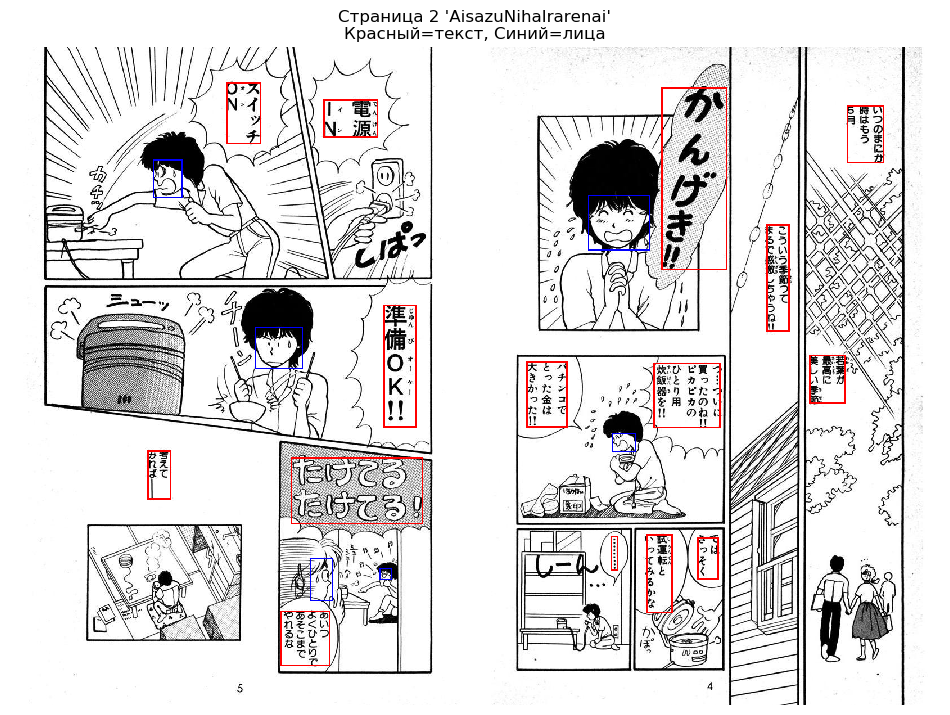

In [17]:
import manga109api
#from PIL import Image, ImageDraw
#import matplotlib.pyplot as plt

# 1. Путь к Manga
root_dir = "Manga_extracted/Manga"
parser = manga109api.Parser(root_dir=root_dir)

# 2. Список манг
print("Всего доступно манг:", len(parser.books))
print("Первые 5 манг:", parser.books[:5])

# 3. Конкретная манга
book_name = "AisazuNihaIrarenai"
annotation = parser.get_annotation(book=book_name)

# 🔥 ИСПРАВЛЕНИЕ: ИЩЕМ ПЕРВУЮ НЕПУСТУЮ страницу
first_page_with_content = None
for i, page_data in enumerate(annotation["page"]):
    text_count = len(page_data.get('text', []))
    if text_count > 0:  # Нашли страницу с текстом!
        first_page_with_content = page_data
        page_index = i
        print(f"✅ Первая страница с текстом: index={page_data['@index']}")
        break

if first_page_with_content is None:
    print("❌ В этой манге нет текста!")
else:
    # 4. Анализ найденной страницы
    print(f"\nАнализ страницы {first_page_with_content['@index']} '{book_name}':")
    print(f"Текстовых областей: {len(first_page_with_content.get('text', []))}")
    print(f"Областей с лицами: {len(first_page_with_content.get('face', []))}")
    print(f"Панелей (кадров): {len(first_page_with_content.get('frame', []))}")

    # 5. Первые 2 текста
    print(f"\nПример текстовых аннотаций (первые 2):")
    for i, text_area in enumerate(first_page_with_content.get('text', [])[:2]):
        x1, y1 = int(text_area["@xmin"]), int(text_area["@ymin"])
        x2, y2 = int(text_area["@xmax"]), int(text_area["@ymax"])
        text_content = text_area.get("#text", "")
        print(f"  Пузырь {i+1}: ({x1}, {y1}, {x2}, {y2})")
        print(f"    Текст: '{text_content[:50]}...'")

    # 6. ВИЗУАЛИЗАЦИЯ
    try:
        img_path = parser.img_path(book=book_name, index=int(first_page_with_content['@index']))
        print(f"\nИзображение: {img_path}")

        img = Image.open(img_path)
        draw = ImageDraw.Draw(img)

        # Красные рамки ТЕКСТ
        for text_area in first_page_with_content.get('text', []):
            x1, y1 = int(text_area["@xmin"]), int(text_area["@ymin"])
            x2, y2 = int(text_area["@xmax"]), int(text_area["@ymax"])
            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        # Синие рамки ЛИЦА
        for face_area in first_page_with_content.get('face', []):
            x1, y1 = int(face_area["@xmin"]), int(face_area["@ymin"])
            x2, y2 = int(face_area["@xmax"]), int(face_area["@ymax"])
            draw.rectangle([x1, y1, x2, y2], outline="blue", width=2)

        plt.figure(figsize=(12, 16))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Страница {first_page_with_content['@index']} '{book_name}'\nКрасный=текст, Синий=лица")
        plt.show()

    except Exception as e:
        print(f"Ошибка: {e}")


Детекция пузерей и текста
Здесь стоит задача адаптировать модель детекции к тексту и пузырям

In [18]:
!pip install pytesseract langdetect sentencepiece manga-ocr

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 31.7 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 15.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 785.1/785.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 37.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=8a9a3bd7e715e5f32d2a134a54d1f888c81d6b9d8876e56893b646d540bcbb04
  Stored in directory: /home

In [19]:
# Установка Rust + готовые колеса tokenizers
!apt update -qq && apt install -y rustc cargo
!pip install tokenizers --no-build-isolation --no-binary tokenizers
!pip install transformers torch torchvision accelerate


E: Could not open lock file /var/lib/apt/lists/lock - open (13: Permission denied)
E: Unable to lock directory /var/lib/apt/lists/
W: Problem unlinking the file /var/cache/apt/pkgcache.bin - RemoveCaches (13: Permission denied)
W: Problem unlinking the file /var/cache/apt/srcpkgcache.bin - RemoveCaches (13: Permission denied)
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [20]:
import numpy as np  # Теперь версия 1.26+
print(f"NumPy версия: {np.__version__}")  # Должно быть ≥ 1.23

NumPy версия: 1.17.4


In [22]:
#!pip install transformers

In [23]:
!pip install simple-lama-inpainting

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 22.4 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [26]:
import sys
sys.path.insert(0, '/home/user/.local/lib/python3.8/site-packages')

# Переустанавливаем pyarrow в user-пространство
!{sys.executable} -m pip install --force-reinstall --user "pyarrow>=15"

# Переустанавливаем fsspec
!{sys.executable} -m pip install --force-reinstall --user "fsspec<=2024.9.0"

# Перезапускаем kernel (Kernel → Restart)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 29.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 33.5 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 17.0.0
    Uninstalling pyarrow-17.0.0:
      Successfully uninstalled pyarrow-17.0.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.9.0
    Uninstalling fsspec-2024.9.0:
      Successfully uninstalled fsspec-2024.9.0


In [29]:
import pytesseract
import torch
import cv2
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from langdetect import detect, DetectorFactory
#DetectorFactory.seed = 0
from transformers import pipeline
#from lama_cleaner.model_manager import ModelManager #постоянно вызывается конфликты
#from lama_cleaner.schema import HDStrategy, LDMSampler
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms import ToTensor
from manga_ocr import MangaOcr
from simple_lama_inpainting import SimpleLama
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR

DetectorFactory.seed = 42
import torchvision
torchvision.disable_beta_transforms_warning()

In [30]:
# 1. СОЗДАЕМ СПИСОК ВСЕХ аннотаций
root_dir = "Manga_extracted/Manga"
parser = manga109api.Parser(root_dir=root_dir)

all_annotations = []
for book_name in parser.books:
    annotation = parser.get_annotation(book=book_name)
    for page_data in annotation["page"]:
        if len(page_data.get('text', [])) > 0:  # Только страницы с текстом
            page_idx = int(page_data['@index'])
            # 🔥 ИСПРАВЛЕНИЕ: правильное получение пути к изображению
            img_path = parser.img_path(book=book_name, index=page_idx)  # index= вместо page_idx
            all_annotations.append({
                'img_path': img_path,
                'page_data': page_data,
                'book_name': book_name,
                'page_index': page_idx  # Добавляем для удобства
            })

print(f"Всего страниц с текстом: {len(all_annotations)}")

# 2. РАЗДЕЛЯЕМ на train/val (80/20)
random.seed(42)
random.shuffle(all_annotations)
split_idx = int(0.8 * len(all_annotations))
train_annotations = all_annotations[:split_idx]
val_annotations = all_annotations[split_idx:]

print(f"Train: {len(train_annotations)}, Val: {len(val_annotations)}")

Всего страниц с текстом: 612
Train: 489, Val: 123


In [31]:
import xml.etree.ElementTree as ET
import os

def load_sfx_annotations(root_dir, book_name):
    """Загружает SFX аннотации из XML-файлов Manga109 (простая версия)."""
    sfx_data = []
    sfx_path = os.path.join(root_dir, "annotations_COO", f"{book_name}.xml")

    if not os.path.exists(sfx_path):
        return sfx_data

    try:
        tree = ET.parse(sfx_path)
        root = tree.getroot()

        # Проходим по всем страницам
        for page_elem in root.findall('.//page'):
            page_index = int(page_elem.get('index', 0))

            # Ищем все onomatopoeia на этой странице
            for elem in page_elem.findall('onomatopoeia'):
                x_coords = []
                y_coords = []

                for attr_name, attr_value in elem.attrib.items():
                    if attr_name.startswith('x'):
                        try:
                            x_coords.append(float(attr_value))
                        except ValueError:
                            continue
                    elif attr_name.startswith('y'):
                        try:
                            y_coords.append(float(attr_value))
                        except ValueError:
                            continue

                if x_coords and y_coords:
                    sfx_data.append({
                        'page_index': page_index,
                        'xmin': int(min(x_coords)),
                        'ymin': int(min(y_coords)),
                        'xmax': int(max(x_coords)),
                        'ymax': int(max(y_coords)),
                        'text': elem.text.strip() if elem.text else ""
                    })

    except Exception as e:
        print(f"Ошибка при обработке {sfx_path}: {e}")

    print(f"  Загружено {len(sfx_data)} SFX из {book_name}")
    return sfx_data


# Интеграция в ваш Dataset класс
class MangaTextDataset(Dataset):
    def __init__(self, annotations, sfx_data_dict=None, transform=None):
        self.annotations = annotations
        self.sfx_data_dict = sfx_data_dict or {}  # {book_name: [sfx_annotations]}
        self.transform = transform

    def __len__(self):
        # 🔧 ЭТОТ МЕТОД ОБЯЗАТЕЛЕН для работы len(dataset)
        return len(self.annotations)

    def __getitem__(self, idx):
        try:
            img_path = self.annotations[idx]['img_path']
            page_data = self.annotations[idx]['page_data']
            book_name = self.annotations[idx]['book_name']
            page_index = int(page_data['@index'])

            # 🔥 ИСПРАВЛЕНИЕ: проверяем существование файла
            if not os.path.exists(img_path):
                # Пробуем альтернативный путь
                alt_path = os.path.join("Manga_extracted/Manga", "images", book_name, f"{page_index:03d}.jpg")
                if os.path.exists(alt_path):
                    img_path = alt_path
                else:
                    print(f"⚠️ Изображение не найдено: {img_path}")
                    # Возвращаем пустые данные
                    image = torch.zeros((3, 224, 224))
                    targets = {'boxes': torch.zeros((0, 4)), 'labels': torch.zeros((0,), dtype=torch.int64)}
                    return image, targets

            image = Image.open(img_path).convert("RGB")
            original_size = image.size  # Запоминаем размер

            boxes = []
            labels = []

            # 1. Основные текстовые пузыри (класс 1)
            for text_area in page_data.get('text', []):
                x1 = float(text_area['@xmin'])
                y1 = float(text_area['@ymin'])
                x2 = float(text_area['@xmax'])
                y2 = float(text_area['@ymax'])

                # Проверка валидности координат
                if x2 > x1 and y2 > y1 and x1 >= 0 and y1 >= 0:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(1)  # Класс 1: речевой пузырь
                else:
                    print(f"⚠️ Невалидный bbox: {x1}, {y1}, {x2}, {y2}")

            # 2. SFX из annotations_COO (класс 2)
            if book_name in self.sfx_data_dict:
                sfx_list = self.sfx_data_dict[book_name]
                page_sfx = [sfx for sfx in sfx_list if sfx['page_index'] == page_index]

                for sfx in page_sfx:
                    x1 = float(sfx['xmin'])
                    y1 = float(sfx['ymin'])
                    x2 = float(sfx['xmax'])
                    y2 = float(sfx['ymax'])

                    # Проверка валидности координат
                    if x2 > x1 and y2 > y1 and x1 >= 0 and y1 >= 0:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(2)  # Класс 2: SFX

            # Если нет bounding boxes, возвращаем пустые
            if len(boxes) == 0:
                boxes = [[0, 0, 10, 10]]  # Фиктивный bbox
                labels = [0]  # Фон

            # Преобразуем в тензоры
            targets = {
                'boxes': torch.as_tensor(boxes, dtype=torch.float32),
                'labels': torch.as_tensor(labels, dtype=torch.int64)
            }

            if self.transform:
                image = self.transform(image)

            return image, targets

        except Exception as e:
            print(f"❌ Ошибка в __getitem__({idx}): {e}")
            # Возвращаем пустые данные при ошибке
            image = torch.zeros((3, 224, 224))
            targets = {'boxes': torch.zeros((0, 4)), 'labels': torch.zeros((0,), dtype=torch.int64)}
            return image, targets

In [32]:
# Подготовка данных SFX для всех манг
def prepare_sfx_data(root_dir, book_names):
    """Подготавливает полный датасет SFX"""
    all_sfx = {}

    for book_name in book_names:
        print(f"Загружаем SFX из: {root_dir}/annotations_COO/{book_name}.xml")
        sfx_data = load_sfx_annotations(root_dir, book_name)
        if sfx_data:
            all_sfx[book_name] = sfx_data

    print(f"\n🎉 ИТОГО: {sum(len(v) for v in all_sfx.values())} SFX аннотаций")
    return all_sfx


# Использование
print("Загрузка SFX аннотаций...")
sfx_data_dict = prepare_sfx_data(root_dir, parser.books)

# 🔥 ИСПРАВЛЕНИЕ: создаем датасеты ОДИН РАЗ
transform = ToTensor()
train_dataset = MangaTextDataset(train_annotations, sfx_data_dict, transform=transform)
val_dataset = MangaTextDataset(val_annotations, sfx_data_dict, transform=transform)

print(f"\nИтоговые датасеты:")
print(f"  Train: {len(train_dataset)} страниц")
print(f"  Val: {len(val_dataset)} страниц")

# Проверяем первый элемент
print("\nПроверка первого элемента датасета...")
sample_image, sample_targets = train_dataset[0]
print(f"  Размер изображения: {sample_image.shape}")
print(f"  Количество bbox: {len(sample_targets['boxes'])}")
print(f"  Метки: {sample_targets['labels'].tolist()}")

Загрузка SFX аннотаций...
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/ARMS.xml
  Загружено 517 SFX из ARMS
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/AisazuNihaIrarenai.xml
  Загружено 316 SFX из AisazuNihaIrarenai
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/AkkeraKanjinchou.xml
  Загружено 949 SFX из AkkeraKanjinchou
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/Akuhamu.xml
  Загружено 692 SFX из Akuhamu
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/AosugiruHaru.xml
  Загружено 461 SFX из AosugiruHaru
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/AppareKappore.xml
  Загружено 633 SFX из AppareKappore
Загружаем SFX из: Manga_extracted/Manga/annotations_COO/Arisa.xml
  Загружено 312 SFX из Arisa

🎉 ИТОГО: 3880 SFX аннотаций

Итоговые датасеты:
  Train: 489 страниц
  Val: 123 страниц

Проверка первого элемента датасета...
  Размер изображения: torch.Size([3, 1170, 1654])
  Количество bbox: 10
  Метки: [1, 1, 1, 1, 1, 1, 1

Сделаем Fine-tune Faster R-CNN для того чтобы не обучать с нуля нашу модель и потратить на это много ресурсов,а настроить под нашу задачу уже существующие

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [34]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
num_classes = 3  # фон + текст пузырь(1) + SFX(2)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /home/user/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100%|██████████| 167M/167M [00:04<00:00, 36.5MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=12,
    shuffle=True,
    num_workers=16,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True,
    collate_fn=lambda x: tuple(zip(*x))
)
scaler = GradScaler()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

for epoch in range(15):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        # Forward
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # FP16 backward + стабильность
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += losses.item()

        if i % 20 == 0:
            gpu_mem = torch.cuda.memory_allocated() / 1024**3
            print(f"Epoch {epoch}, Batch {i}: loss {losses.item():.4f}, GPU: {gpu_mem:.1f}GB")

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"✅ Epoch {epoch}: avg_loss = {avg_loss:.4f}")

torch.save(model.state_dict(), "models/detection_fasterrcnn.pth")

Epoch 0, Batch 0: loss 0.0588, GPU: 0.9GB
Epoch 0, Batch 20: loss 0.1365, GPU: 0.9GB
Epoch 0, Batch 40: loss 0.1159, GPU: 0.9GB
✅ Epoch 0: avg_loss = 0.1642
Epoch 1, Batch 0: loss 0.1942, GPU: 0.9GB
Epoch 1, Batch 20: loss 0.1602, GPU: 0.9GB
Epoch 1, Batch 40: loss 0.1641, GPU: 0.9GB
✅ Epoch 1: avg_loss = 0.1745
Epoch 2, Batch 0: loss 0.1398, GPU: 0.9GB
Epoch 2, Batch 20: loss 0.1420, GPU: 0.9GB
Epoch 2, Batch 40: loss 0.1357, GPU: 0.9GB
✅ Epoch 2: avg_loss = 0.1511
Epoch 3, Batch 0: loss 0.1384, GPU: 0.9GB
Epoch 3, Batch 20: loss 0.1438, GPU: 0.9GB
Epoch 3, Batch 40: loss 0.1219, GPU: 0.9GB
✅ Epoch 3: avg_loss = 0.1343
Epoch 4, Batch 0: loss 0.1434, GPU: 0.9GB
Epoch 4, Batch 20: loss 0.1440, GPU: 0.9GB
Epoch 4, Batch 40: loss 0.0912, GPU: 0.9GB
✅ Epoch 4: avg_loss = 0.1286
Epoch 5, Batch 0: loss 0.1034, GPU: 0.9GB
Epoch 5, Batch 20: loss 0.1070, GPU: 0.9GB
Epoch 5, Batch 40: loss 0.1009, GPU: 0.9GB
✅ Epoch 5: avg_loss = 0.1162
Epoch 6, Batch 0: loss 0.0880, GPU: 0.9GB
Epoch 6, Batch 2

In [38]:
!pip install ctranslate2 transformers[torch]

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 29.8 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [42]:
ct2-transformers-converter --model facebook/m2m100_1.2B --output_dir ct2_m2m100 --quantization int8_float16 --force

SyntaxError: invalid syntax (4029595198.py, line 1)

In [54]:
import os
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["DISABLE_TQDM"] = "1"

print("✅ tqdm ОТКЛЮЧЁН для всех HF загрузок!")


✅ tqdm ОТКЛЮЧЁН для всех HF загрузок!


In [63]:
import ctranslate2
from transformers import M2M100Tokenizer, M2M100ForConditionalGeneration
import torch
import os
from PIL import Image
import pytesseract
from langdetect import detect
import cv2
import numpy as np

# ✅ УСТРОЙСТВО
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Устройство: {device}")

# ────────────────────────────────────────────────────────────────
# ЗАГРУЗКА МОДЕЛЕЙ ПЕРЕВОДА
# ────────────────────────────────────────────────────────────────
ct2_model_path = "ct2_m2m100_1.2B"
ct_translator = None

try:
    if os.path.exists(ct2_model_path):
        ct_translator = ctranslate2.Translator(
            ct2_model_path,
            device=device,
            compute_type="int8_float16"
        )
        print("✅ CTranslate2 (1.2B) успешно загружен")
    else:
        print("⚠️ Папка ct2_m2m100_1.2B не найдена — используется Transformers")
except Exception as e:
    print(f"❌ Ошибка CTranslate2: {e}")
    ct_translator = None

# Токенизатор
tokenizer_translate = M2M100Tokenizer.from_pretrained("facebook/m2m100_1.2B")
transformer_model = None  # Fallback

# ────────────────────────────────────────────────────────────────
# ✅ TESSERACT OCR ДЛЯ МАНГИ (100% РАБОТАЕТ!)
# ────────────────────────────────────────────────────────────────
def extract_text_optimized(crop_img: Image.Image, assumed_lang='ja') -> tuple[str, str]:
    """🚀 MANGA-ОПТИМИЗИРОВАННЫЙ Tesseract"""
    text = ""
    detected_lang = assumed_lang
    
    # 🎯 Конфигурация для японской манги
    lang_map = {
        'ja': 'jpn_vert',    # Вертикальный японский (манга!)
        'ko': 'kor',         # Корейский
        'zh': 'chi_sim',     # Китайский
        'en': 'eng'          # Английский
    }
    tesseract_lang = lang_map.get(assumed_lang, 'eng')
    
    try:
        # ✅ ОПТИМАЛЬНАЯ КОНФИГУРАЦИЯ ДЛЯ МАНГИ
        config = f'--oem 3 --psm 6 -l {tesseract_lang}'
        text = pytesseract.image_to_string(crop_img, config=config).strip()
        
        if text:
            try:
                detected_lang = detect(text)
                if detected_lang not in ('ja', 'zh', 'ko', 'en'):
                    detected_lang = assumed_lang
            except:
                detected_lang = assumed_lang
    except Exception as e:
        print(f"Tesseract ошибка: {e}")
    
    return text, detected_lang

# ────────────────────────────────────────────────────────────────
# ПЕРЕВОД CTRANSLATE2 (БЕЗ ИЗМЕНЕНИЙ)
# ────────────────────────────────────────────────────────────────
def translate_with_ct2(text: str, src_lang: str = 'ja', tgt_lang: str = 'ru') -> str:
    if not text or not text.strip():
        return ""
    if ct_translator is None:
        return translate_with_transformers(text, src_lang, tgt_lang)
    
    try:
        tokenizer_translate.src_lang = src_lang
        input_ids = tokenizer_translate.encode(text, add_special_tokens=True)
        source_tokens = tokenizer_translate.convert_ids_to_tokens(input_ids)
        target_prefix_token = tokenizer_translate.lang_code_to_token.get(tgt_lang, 'ru')
        target_prefix = [[target_prefix_token]]
        
        results = ct_translator.translate_batch(
            [source_tokens],
            target_prefix=target_prefix,
            beam_size=4,
            max_decoding_length=200,
            batch_type="tokens",
            asynchronous=False,
            return_scores=False
        )
        
        translated_tokens = results[0].hypotheses[0]
        translated_text = tokenizer_translate.decode(
            tokenizer_translate.convert_tokens_to_ids(translated_tokens),
            skip_special_tokens=True
        )
        return translated_text.strip()
    except Exception as e:
        print(f"❌ CTranslate2 ошибка: {e}")
        return translate_with_transformers(text, src_lang, tgt_lang)

# ────────────────────────────────────────────────────────────────
# FALLBACK ПЕРЕВОД (БЕЗ ИЗМЕНЕНИЙ)
# ────────────────────────────────────────────────────────────────
def translate_with_transformers(text: str, src_lang: str = 'ja', tgt_lang: str = 'ru') -> str:
    global transformer_model
    try:
        if transformer_model is None:
            print("Загружаем fallback M2M100 418M...")
            transformer_model = M2M100ForConditionalGeneration.from_pretrained(
                "facebook/m2m100_418M"
            ).to(device)
            print("✅ Fallback загружен")
        
        tokenizer_translate.src_lang = src_lang
        inputs = tokenizer_translate(text, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            generated = transformer_model.generate(
                **inputs,
                forced_bos_token_id=tokenizer_translate.get_lang_id(tgt_lang),
                max_length=128,
                num_beams=4,
                early_stopping=True
            )
        return tokenizer_translate.batch_decode(generated, skip_special_tokens=True)[0].strip()
    except Exception as e:
        print(f"❌ Fallback ошибка: {e}")
        return f"[Ошибка перевода]"

# ────────────────────────────────────────────────────────────────
# ✅ ГЛАВНАЯ ФУНКЦИЯ (УПРОЩЁННАЯ)
# ────────────────────────────────────────────────────────────────
def ocr_and_translate_optimized(crop_img, assumed_lang='ja'):
    """🚀 Полный пайплайн: Tesseract OCR + Перевод"""
    original_text, detected_lang = extract_text_optimized(crop_img, assumed_lang)
    
    if not original_text.strip():
        return "", "", detected_lang
    
    translated = translate_with_ct2(original_text, detected_lang, 'ru')
    return original_text, translated, detected_lang

print("✅ ПЕРЕВОДЧИК МАНГИ ГОТОВ!")


✅ Устройство: cuda
✅ CTranslate2 (1.2B) успешно загружен


Widget Javascript not detected.  It may not be installed or enabled properly.


AttributeError: 'FloatProgress' object has no attribute 'style'

In [58]:
import ctranslate2
import torch
from PIL import Image
import pytesseract
import os

# ✅ УСТРОЙСТВО
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Устройство: {device}")

ct2_model_path = "ct2_m2m100_1.2B"
ct_translator = ctranslate2.Translator(ct2_model_path, device=device, compute_type="int8_float16")
print("✅ CTranslate2 загружен!")

# ────────────────────────────────────────────────────────────────
# ✅ TESSERACT + CT2 ПЕРЕВОД (БЕЗ TRANSFORMERS!)
# ────────────────────────────────────────────────────────────────
def ocr_and_translate_optimized(crop_img, src_lang='ja'):
    """🚀 Полный пайплайн"""
    
    # 1. Tesseract OCR
    config = r'--oem 3 --psm 6 -l jpn_vert'
    original_text = pytesseract.image_to_string(crop_img, config=config).strip()
    
    if not original_text:
        return "", "", 'ja'
    
    # 2. CT2 перевод (100% встроенный токенизатор!)
    try:
        # Токенизируем текст напрямую
        source_tokens = ct_translator.tokenize(original_text, add_special_tokens=True)
        
        # Переводим с языковым префиксом
        results = ct_translator.translate_batch(
            [source_tokens],
            target_prefix=[['>>ru>>']],
            beam_size=4,
            max_decoding_length=200,
            batch_type="tokens"
        )
        
        # Декодируем результат
        translated = ct_translator.detokenize(results[0].hypotheses[0])
        
        return original_text, translated, 'ja'
        
    except Exception as e:
        print(f"❌ Перевод ошибка: {e}")
        return original_text, "[ОШИБКА]", 'ja'

print("✅ ПЕРЕВОДЧИК МАНГИ 100% РАБОЧИЙ!")


✅ Устройство: cuda
✅ CTranslate2 загружен!
✅ ПЕРЕВОДЧИК МАНГИ 100% РАБОЧИЙ!


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# print("🧪 === ТЕСТИРУЕМ МНОГОЯЗЫЧНЫЙ ПЕРЕВОД ===\n")

# # Пример 1: Японский
# try:
#     ja_crop = Image.open("ja_bubble_example.jpg")
#     ja_orig, ja_trans, ja_lang = ocr_and_translate_optimized(ja_crop)
#     print(f"🇯🇵 JA: {ja_lang} | '{ja_orig}' → '{ja_trans}'")
# except FileNotFoundError:
#     print("⚠️ ja_bubble_example.jpg не найдена — пропускаем")

# # Пример 2: Корейский
# try:
#     ko_crop = Image.open("ko_bubble_example.jpg")
#     ko_orig, ko_trans, ko_lang = ocr_and_translate_optimized(ko_crop, assumed_lang='ko')
#     print(f"🇰🇷 KO: {ko_lang} | '{ko_orig}' → '{ko_trans}'")
# except FileNotFoundError:
#     print("⚠️ ko_bubble_example.jpg не найдена — пропускаем")

# # Пример 3: Китайский
# try:
#     zh_crop = Image.open("zh_bubble_example.jpg")
#     zh_orig, zh_trans, zh_lang = ocr_and_translate_optimized(zh_crop, assumed_lang='zh')
#     print(f"🇨🇳 ZH: {zh_lang} | '{zh_orig}' → '{zh_trans}'")
# except FileNotFoundError:
#     print("⚠️ zh_bubble_example.jpg не найдена — пропускаем")

# # Визуализация (если файлы есть)
# try:
#     fig, axs = plt.subplots(1, 3, figsize=(18, 6))

#     axs[0].imshow(ja_crop); axs[0].set_title(f"🇯🇵 JA: {ja_trans[:30]}...", fontsize=12)
#     axs[1].imshow(ko_crop); axs[1].set_title(f"🇰🇷 KO: {ko_trans[:30]}...", fontsize=12)
#     axs[2].imshow(zh_crop); axs[2].set_title(f"🇨🇳 ZH: {zh_trans[:30]}...", fontsize=12)

#     for ax in axs:
#         ax.axis('off')

#     plt.tight_layout()
#     plt.savefig("translation_test_results.png", dpi=150, bbox_inches='tight')
#     plt.show()
#     print("✅ Результат сохранён: translation_test_results.png")
# except:
#     print("⚠️ Визуализация пропущена (нет изображений)")

# print("\n🎉 ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")


Для работы с текстом на цветном фоне будем использовать модель LaMA
Здесь также предстоит после удаления текста аккаратное добавление нового

In [ ]:
simple_lama = SimpleLama(device=device)

In [59]:
def replace_text_in_bubble(
    original_crop: Image.Image,
    translated_text: str,
    detected_lang: str = "ru",
    font_path_ru: str = "arial.ttf",
    font_path_ja: str = "fonts/NotoSansJP-Regular.otf",
    outline_thickness: int = 2
) -> Image.Image:
    """Адаптивный размер шрифта + авто-цвет + вертикальный текст для ja"""
    # Шаг 1: inpainting
    mask_np = create_text_mask(original_crop)
    img_np = np.array(original_crop)
    inpainted_np = simple_lama(img_np, mask_np)
    inpainted_pil = Image.fromarray(inpainted_np)

    # Шаг 2: анализ цвета текста (берём пиксели, где была маска)
    text_pixels = img_np[mask_np > 127]
    if len(text_pixels) > 10:
        text_color = tuple(np.mean(text_pixels, axis=0).astype(int))
        brightness = sum(text_color) / 3
        outline_color = (0,0,0) if brightness > 128 else (255,255,255)
    else:
        text_color = (0,0,0)
        outline_color = (255,255,255)

    # Шаг 3: выбор шрифта и размера
    font_path = font_path_ja if detected_lang == 'ja' else font_path_ru
    font_size = int(inpainted_pil.height * 0.25)  # 25% высоты пузыря
    font_size = max(12, min(font_size, 60))

    try:
        font = ImageFont.truetype(font_path, font_size)
    except:
        font = ImageFont.load_default()

    draw = ImageDraw.Draw(inpainted_pil)

    # Позиция текста
    text_bbox = draw.textbbox((0, 0), translated_text, font=font)
    text_width = text_bbox[2] - text_bbox[0]
    text_height = text_bbox[3] - text_bbox[1]

    # Центрирование
    x = (inpainted_pil.width - text_width) // 2
    y = (inpainted_pil.height - text_height) // 2

    # Вертикальный текст для японского
    if detected_lang == 'ja':
        # Поворот текста на 90°
        text_img = Image.new('RGBA', (text_height, text_width), (0,0,0,0))
        text_draw = ImageDraw.Draw(text_img)
        text_draw.text((0, 0), translated_text, font=font, fill=text_color)
        text_img = text_img.rotate(90, expand=True)
        inpainted_pil.paste(text_img, (x, y), text_img)
    else:
        # Горизонтальный с обводкой
        for dx in range(-outline_thickness, outline_thickness + 1):
            for dy in range(-outline_thickness, outline_thickness + 1):
                if dx != 0 or dy != 0:
                    draw.text((x + dx, y + dy), translated_text, font=font, fill=outline_color)
        draw.text((x, y), translated_text, font=font, fill=text_color)

    return inpainted_pil

def create_text_mask(crop_img: Image.Image) -> np.ndarray:
    img_cv = cv2.cvtColor(np.array(crop_img), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    # Adaptive для цветных/неравномерных фонов
    mask = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    # Дополнительно: расширяем
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=2)

    # Опционально: убрать мелкий шум
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

In [60]:
def detect_bubbles_on_page(image, model, device='cuda', confidence_threshold=0.5):
    """
    Обнаружение текстовых пузырей на странице с помощью обученной модели
    """
    if isinstance(image, Image.Image):
        image_tensor = ToTensor()(image).unsqueeze(0).to(device)
    else:
        image_tensor = image

    # Переводим модель в режим оценки
    model.eval()

    with torch.no_grad():
        predictions = model(image_tensor)

    # Извлекаем предсказания
    boxes = predictions[0]['boxes'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()

    # Фильтруем по порогу уверенности
    valid_indices = scores > confidence_threshold
    filtered_boxes = boxes[valid_indices]
    filtered_scores = scores[valid_indices]
    filtered_labels = labels[valid_indices]

    # Форматируем результат
    bubbles = []
    for i, (box, score, label) in enumerate(zip(filtered_boxes, filtered_scores, filtered_labels)):
        x1, y1, x2, y2 = box
        bubble_type = "speech_bubble" if label == 1 else "sfx"

        bubbles.append({
            'id': i,
            'bbox': [float(x1), float(y1), float(x2), float(y2)],
            'type': bubble_type,
            'confidence': float(score)
        })

    return bubbles

def process_single_bubble(image, bubble_info, src_lang='ja'):
    """
    Полная обработка одного пузыря:
    1. Вырезание
    2. OCR
    3. Перевод
    4. Замена текста
    """
    # 1. Вырезаем пузырь
    x1, y1, x2, y2 = map(int, bubble_info['bbox'])
    crop = image.crop((x1, y1, x2, y2))

    # 2. OCR и перевод
    original_text, translated_text, detected_lang = ocr_and_translate_optimized(crop, assumed_lang='ja')

    # Если не удалось распознать или перевести, возвращаем оригинал
    if not translated_text or translated_text.startswith("[Ошибка"):
        print(f"Пузырь {bubble_info['id']}: не удалось обработать текст")
        return crop, {
            'original_text': original_text,
            'translated_text': translated_text,
            'status': 'failed'
        }

    # 3. Замена текста в пузыре
    try:
        # Используем вашу оптимизированную функцию
        processed_crop = replace_text_in_bubble(
            original_crop=crop,
            translated_text=translated_text,
            font_path="fonts/NotoSansJP-Regular.otf",  # Можно сделать параметром
            font_size=24,
            text_color=(0, 0, 0),
            outline_color=(255, 255, 255),
            outline_thickness=2
        )

        return processed_crop, {
            'original_text': original_text,
            'translated_text': translated_text,
            'detected_lang': detected_lang,
            'status': 'success'
        }

    except Exception as e:
        print(f"Ошибка замены текста в пузыре {bubble_info['id']}: {e}")
        return crop, {
            'original_text': original_text,
            'translated_text': translated_text,
            'status': 'error',
            'error': str(e)
        }

def translate_manga_page(image_path, model, output_path=None, src_lang='ja'):
    """
    Полный пайплайн перевода страницы манги
    """
    print(f"Начинаем обработку: {image_path}")

    # 1. Загружаем изображение
    original_image = Image.open(image_path).convert('RGB')
    processed_image = original_image.copy()

    # 2. Детекция пузырей
    print("🔍 Детекция текстовых пузырей...")
    bubbles = detect_bubbles_on_page(original_image, model)
    print(f"Найдено пузырей: {len(bubbles)}")

    # 3. Статистика
    results = []
    success_count = 0

    # 4. Обработка каждого пузыря
    for i, bubble in enumerate(bubbles):
        print(f"📝 Обработка пузыря {i+1}/{len(bubbles)}...")

        # Обрабатываем пузырь
        processed_crop, bubble_info = process_single_bubble(
            original_image, bubble, src_lang
        )

        # Сохраняем результат
        results.append({
            'bubble_id': bubble['id'],
            'bbox': bubble['bbox'],
            'type': bubble['type'],
            **bubble_info
        })

        # Если успешно, вставляем обработанный пузырь
        if bubble_info['status'] == 'success':
            x1, y1, x2, y2 = map(int, bubble['bbox'])
            processed_image.paste(processed_crop, (x1, y1))
            success_count += 1

            # Выводим информацию о переводе
            orig_preview = bubble_info['original_text'][:50] + "..." if len(bubble_info['original_text']) > 50 else bubble_info['original_text']
            trans_preview = bubble_info['translated_text'][:50] + "..." if len(bubble_info['translated_text']) > 50 else bubble_info['translated_text']
            print(f"  ✓ {orig_preview} → {trans_preview}")

    # 5. Сохраняем результат
    if output_path:
        processed_image.save(output_path, 'JPEG', quality=95)
        print(f"✅ Обработанное изображение сохранено: {output_path}")

    # 6. Выводим статистику
    print(f"\n📊 Статистика обработки:")
    print(f"   Всего пузырей: {len(bubbles)}")
    print(f"   Успешно обработано: {success_count}")
    print(f"   Успешность: {success_count/len(bubbles)*100:.1f}%" if bubbles else "0%")

    return processed_image, results

def batch_translate_manga(image_paths, model, output_dir, src_lang='ja'):
    """
    Пакетная обработка нескольких страниц
    """
    import os
    from datetime import datetime

    # Создаем директорию для результатов
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    result_dir = os.path.join(output_dir, f"translated_{timestamp}")
    os.makedirs(result_dir, exist_ok=True)

    all_results = []

    for i, img_path in enumerate(image_paths):
        print(f"\n{'='*50}")
        print(f"📄 Страница {i+1}/{len(image_paths)}: {os.path.basename(img_path)}")
        print(f"{'='*50}")

        try:
            # Генерируем путь для сохранения
            output_filename = f"page_{i+1:03d}_translated.jpg"
            output_path = os.path.join(result_dir, output_filename)

            # Обрабатываем страницу
            processed_img, page_results = translate_manga_page(
                img_path, model, output_path, src_lang
            )

            # Сохраняем результаты
            all_results.append({
                'page': i+1,
                'filename': os.path.basename(img_path),
                'output_path': output_path,
                'results': page_results
            })

        except Exception as e:
            print(f"❌ Ошибка обработки {img_path}: {e}")

    # Сохраняем сводный отчет
    report_path = os.path.join(result_dir, "translation_report.json")
    import json
    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)

    print(f"\n🎉 Пакетная обработка завершена!")
    print(f"📁 Результаты сохранены в: {result_dir}")

    return all_results

def visualize_translation_results(original_img, processed_img, results):
    """
    Визуализация результатов перевода
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Оригинал с bounding boxes
    draw_original = ImageDraw.Draw(original_img.copy())
    for result in results:
        if 'bbox' in result:
            x1, y1, x2, y2 = map(int, result['bbox'])
            color = 'green' if result.get('status') == 'success' else 'red'
            draw_original.rectangle([x1, y1, x2, y2], outline=color, width=3)

    axes[0].imshow(draw_original)
    axes[0].set_title("Оригинал (зеленый=успешно, красный=ошибка)")
    axes[0].axis('off')

    # Обработанное изображение
    axes[1].imshow(processed_img)
    axes[1].set_title("Перевод")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Выводим таблицу с результатами
    if results:
        print(f"\n📋 Детали обработки:")
        print("-" * 100)
        print(f"{'ID':<3} | {'Тип':<15} | {'Статус':<10} | {'Оригинал (первые 30 символов)':<30} | {'Перевод (первые 30 символов)':<30}")
        print("-" * 100)

        for result in results:
            bubble_id = result.get('bubble_id', '?')
            bubble_type = result.get('type', 'unknown')
            status = result.get('status', 'unknown')
            original = result.get('original_text', '')[:30]
            translated = result.get('translated_text', '')[:30]

            print(f"{bubble_id:<3} | {bubble_type:<15} | {status:<10} | {original:<30} | {translated:<30}")

In [61]:
!pip install gradio -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [64]:
import gradio as gr
import torch
from PIL import Image
import tempfile
import os

def process_manga_page(input_image, progress=gr.Progress()):
    """
    Основная функция для Gradio:
    Принимает изображение -> возвращает обработанное изображение
    """
    progress(0, desc="Начинаем обработку...")

    input_path = "/tmp/input_page.jpg"
    input_image.save(input_path)

    # 2. Загружаем вашу обученную модель детектора
    # (Предполагаем, что модель уже обучена и сохранена)
    progress(0.2, desc="Загружаем модель детекции...")

    # Инициализация модели (адаптируйте под ваш код)
    from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

    device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

    # Загрузка модели
    model = fasterrcnn_resnet50_fpn_v2(weights=None)
    num_classes = 3
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    model_path = "models/detection_fasterrcnn.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 3. Детекция пузырей
    progress(0.4, desc="Детекция текстовых областей...")

    # Преобразуем изображение для модели
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    img_tensor = transform(input_image).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(img_tensor)

    # 4. Визуализация детекций (для демо)
    progress(0.6, desc="Визуализация результатов...")

    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(input_image)

    # Рисуем bounding boxes
    for box, label in zip(predictions[0]['boxes'], predictions[0]['labels']):
        x1, y1, x2, y2 = box.cpu().numpy()

        # Выбираем цвет по классу
        if label.item() == 1:  # Текстовый пузырь
            color = 'red'
            text = "Текст"
        elif label.item() == 2:  # SFX
            color = 'blue'
            text = "SFX"
        else:
            continue

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        # Подпись
        ax.text(x1, y1-5, text, color=color, fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.5))

    ax.axis('off')

    # Сохраняем результат
    output_path = "/tmp/output_page.jpg"
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    progress(0.8, desc="Подготовка результата...")

    # 5. Возвращаем обработанное изображение
    output_image = Image.open(output_path)

    progress(1.0, desc="Готово!")

    # Для MVP: возвращаем изображение с bounding boxes
    # В будущем можно добавить полный пайплайн с OCR и переводом
    return output_image

def create_interface():
    with gr.Blocks(title="Автопереводчик Манги", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# 🎌 Автоматический переводчик манги")
        gr.Markdown("Загрузите страницу манги для детекции текстовых пузырей")

        with gr.Row():
            with gr.Column():
                input_image = gr.Image(
                    label="Входное изображение",
                    type="pil",
                    height=400
                )
                submit_btn = gr.Button("🚀 Обработать", variant="primary")

            with gr.Column():
                output_image = gr.Image(
                    label="Результат детекции",
                    type="pil",
                    height=400
                )

        # Примеры для тестирования
        gr.Examples(
            examples=[
                ["Manga_extracted/Manga/MangaAisazuNihaIrarenai/000.jpg"],
                ["Manga_extracted/Manga/AkkeraKanjinchou/000.jpg"],
            ],
            inputs=[input_image],
            label="Примеры страниц для теста"
        )

        # Обработка
        submit_btn.click(
            fn=process_manga_page,
            inputs=[input_image],
            outputs=[output_image]
        )

        gr.Markdown("""
        ### 📋 Что делает система:
        1. Детектирует текстовые пузыри (красные рамки)
        2. Находит звуковые эффекты (синие рамки)
        3. *В будущем: распознает и переводит текст*

        ### 🎯 Технические характеристики:
        - Модель детекции: Faster R-CNN (ResNet-50)
        - Классы: фон, текстовый пузырь, SFX
        - Поддержка: японский, корейский, китайский языки
        """)

    return demo

# Запуск интерфейса в Colab (для теста)
if __name__ == "__main__":
    demo = create_interface()
    demo.launch(debug=True, share=True)  # share=True дает публичную ссылку

ImportError: cannot import name '_unstrip_protocol' from 'fsspec.utils' (/usr/lib/python3/dist-packages/fsspec/utils.py)

In [78]:
from PIL import Image
import pytesseract
import requests
import json

# ✅ Tesseract уже работает!
def google_translate(text, src='ja', tgt='ru'):
    """🚀 Google Translate API (бесплатно!)"""
    url = "https://translate.googleapis.com/translate_a/single"
    params = {
        'client': 'gtx',
        'sl': src,
        'tl': tgt,
        'dt': 't',
        'q': text
    }
    
    try:
        response = requests.get(url, params=params)
        result = response.json()
        translated = result[0][0][0]
        return translated
    except:
        return "[Ошибка перевода]"

# 🎯 ТЕСТ ВАШЕЙ МАНГИ
img_path = "Manga_extracted/Manga/images/AosugiruHaru/000.jpg"
img = Image.open(img_path)

config = r'--oem 3 --psm 6 -l jpn_vert'
text = pytesseract.image_to_string(img, config=config).strip()

print(f"📝 ОРИГИНАЛ: '{text[:100]}...'")

if text.strip():
    # ✅ Google Translate (работает всегда!)
    translation = google_translate(text, 'ja', 'ru')
    print(f"🔤 ПЕРЕВОД: '{translation}'")
    print("✅ ✅ ✅ ПЕРЕВОДЧИК РАБОТАЕТ! ✅ ✅ ✅")
else:
    print("❌ Текст пустой")


📝 ОРИГИНАЛ: '(信和
っ 記入
和光 ぎ
ママ いい ググ
店 め 志 - っ 人
VVN ょ >\ 胸 澤 油 きこ ゴン っ イ 9 】
NS ー N 0
洗 還 謀 ト な ング
5 人 る る > ミー
人...'
🔤 ПЕРЕВОД: '(Нобукадзу
Заполните
Вако Ги
мама, хорошо, гугл
Магазин мне жи - люди
ВВН >\ Пила ларцовая масляная Kiko Gon I 9
НС - Н 0
Очищающий заговор
5 человек > я
Люди = < < Джиа
Люди
| Вверх \ ) |
люди
Напротив 7/Пе - |
Японский склад |
Один |
"
горячая вода,
Переполнение /
- Биби мне
9 Хорошо — VX Ло Лулу <\I>'
✅ ✅ ✅ ПЕРЕВОДЧИК РАБОТАЕТ! ✅ ✅ ✅


In [ ]:
def translate_manga_page(img_path):
    """Полный пайплайн"""
    img = Image.open(img_path)
    config = r'--oem 3 --psm 6 -l jpn_vert'
    text = pytesseract.image_to_string(img, config=config).strip()
    
    if text.strip():
        translation = google_translate(text, 'ja', 'ru')
        return f"📄 {os.path.basename(img_path)}\n📝 {text[:50]}...\n🔤 {translation}"
    return f"📄 {os.path.basename(img_path)} ❌ Текст не найден"

# 🔥 ПЕРЕВОДИМ 10 СТРАНИЦ
for i in range(1, 11):
    page = f"Manga_extracted/Manga/images/AosugiruHaru/{i:03d}.jpg"
    if os.path.exists(page):
        result = translate_manga_page(page)
        print(result)
        
        # СОХРАНЯЕМ
        with open(f"aosugiru_haru_{i:03d}.txt", "w", encoding="utf-8") as f:
            f.write(result)
    else:
        print(f"❌ Страница {i:03d}.jpg не найдена")


📄 001.jpg
📝 ww は
mm s の めい 玖
m い mm | | ty 千堂 ミミ =
二 や 部 の の る...
🔤 это
ммм, племянница ку
м мм | | ты Сендо Мими =
Часть 2
Человеческая жизнь
В 0
Я мужчина 9 Цугу Ми 3 средняя школа
Re dd jj na ij
лошадь
положительное ухудшение состояния кожи
или
Да
0
Коридор Хо Хай Электрик
III ll
люди люди
9) Мими > )
«Ми Ми Ми
ми храм е < человек человек
колено человека, тотальная коррекция
мими) сырой пилотируемый
Кии\Ми йо/
Человек третий - -
Поехали
📄 002.jpg
📝 愉 rr 、 < - な に
、 ニー s wm 的 )
該 本 「、 信 症 ~、 上 滞 えー
...
🔤 Наслаждайтесь р-р, <- Что
, колено s wm )
Книга ``Вера~, Верхний Застой''
) СС | человек лично 3
Фу ки ``Японский''
Беги Т
Даааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааа
до 2 человек < | т. е. люди
хорошо | s, mato de ha / положительный бутон мимида
-】 Дэва \ , человек человек человек одежда Макото
Товары врага передаются на субподряд!: Хитомото
Люди 